In [82]:
# first upload the data/ folder to the content/ directory of the Colab environment
# then run this script to load the data and train the model

In [83]:
# uncomment these to check if the GPU is available and being used
!nvidia-smi

Fri May  1 09:39:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0             31W /   70W |     357MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [84]:
# uncomment these ifyou want to mount your Google Drive to access the data or sve the model artificats generated during training

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

Libraries imported successfully!
TensorFlow version: 2.20.0


In [86]:
# Load the CSV file
# Make sure to first upload the data/ folder to the content/ directory of the Colab environment before running this cell
df = pd.read_csv('/content/data/feature_store/reg_ts_categorised_weather_data_with_features.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:") 
display(df.head())

print("\nDataset info:")
print(df.info())

print("\nBasic statistics:")
display(df.describe())

Dataset shape: (1122, 35)

First 5 rows:


,Date,Time,Total Rainfall,Dry bulb,Wet bulb,Humidity,Wind speed,datetime,log_rainfall_ts,hour,...,rainfall_lag_2,humidity_lag_2,drybulb_lag_2,rainfall_lag_3,humidity_lag_3,drybulb_lag_3,rainfall_roll_3h,humidity_roll_3h,drybulb_roll_3h,log_rainfall_reg
0,3/1/2023,14:00,0.0,26.5,20.2,55.0,4,2023-03-01 14:00:00,0.000000,14,...,0.0,65.0,25.0,0.0,70.0,23.5,0.000000,58.333333,25.900000,0.000000
1,3/1/2023,15:00,0.0,27.4,20.6,53.0,6,2023-03-01 15:00:00,0.000000,15,...,0.0,55.0,26.2,0.0,65.0,25.0,0.000000,54.333333,26.700000,0.000000
2,3/1/2023,16:00,0.0,27.0,20.5,54.0,4,2023-03-01 16:00:00,0.000000,16,...,0.0,55.0,26.5,0.0,55.0,26.2,0.000000,54.000000,26.966667,0.000000
3,3/2/2023,8:00,83.3,19.8,18.4,88.0,0,2023-03-02 08:00:00,4.434382,8,...,0.0,53.0,27.4,0.0,55.0,26.5,27.766667,65.000000,24.733333,4.434382
4,3/2/2023,9:00,83.3,20.5,18.5,83.0,2,2023-03-02 09:00:00,4.434382,9,...,0.0,54.0,27.0,0.0,53.0,27.4,55.533333,75.000000,22.433333,4.434382



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 35 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1122 non-null   object 
 1   Time              1122 non-null   object 
 2   Total Rainfall    1122 non-null   float64
 3   Dry bulb          1122 non-null   float64
 4   Wet bulb          1122 non-null   float64
 5   Humidity          1122 non-null   float64
 6   Wind speed        1122 non-null   int64  
 7   datetime          1122 non-null   object 
 8   log_rainfall_ts   1122 non-null   float64
 9   hour              1122 non-null   int64  
 10  rain_category     1122 non-null   int64  
 11  rain_label        1122 non-null   object 
 12  date              1122 non-null   object 
 13  month             1122 non-null   int64  
 14  day               1122 non-null   int64  
 15  year              1122 non-null   int64  
 16  dayofweek         1122 non-

,Total Rainfall,Dry bulb,Wet bulb,Humidity,Wind speed,log_rainfall_ts,hour,rain_category,month,day,...,rainfall_lag_2,humidity_lag_2,drybulb_lag_2,rainfall_lag_3,humidity_lag_3,drybulb_lag_3,rainfall_roll_3h,humidity_roll_3h,drybulb_roll_3h,log_rainfall_reg
count,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,...,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000
mean,6.721212,23.775936,20.153832,73.256684,2.188057,1.080966,12.022282,1.220143,4.540107,15.787879,...,6.748841,73.388592,23.747504,6.726471,73.406417,23.744652,6.739097,73.309566,23.763963,1.080966
std,12.777647,2.833518,0.939114,13.346146,2.018054,1.288908,2.580453,1.163151,1.127348,8.645435,...,12.851207,13.380874,2.839397,12.837700,13.419954,2.846237,12.127712,11.086064,2.384586,1.288908
min,0.000000,17.000000,16.800000,44.000000,0.000000,0.000000,8.000000,0.000000,3.000000,1.000000,...,0.000000,44.000000,17.000000,0.000000,44.000000,17.000000,0.000000,46.000000,17.166667,0.000000
25%,0.000000,21.400000,19.500000,62.000000,0.000000,0.000000,10.000000,0.000000,4.000000,8.000000,...,0.000000,62.000000,21.400000,0.000000,62.000000,21.400000,0.000000,64.750000,22.133333,0.000000
50%,0.500000,24.400000,20.400000,70.000000,2.000000,0.405465,12.000000,1.000000,5.000000,16.000000,...,0.400000,70.000000,24.300000,0.400000,70.000000,24.300000,0.650000,72.333333,23.900000,0.405465
75%,7.300000,26.000000,21.000000,84.000000,4.000000,2.116256,14.000000,2.000000,6.000000,23.000000,...,7.300000,84.000000,26.000000,7.300000,85.000000,26.000000,7.800000,80.333333,25.533333,2.116256
max,83.300000,30.200000,22.400000,100.000000,8.000000,4.434382,16.000000,3.000000,6.000000,31.000000,...,83.300000,100.000000,30.200000,83.300000,100.000000,30.200000,83.300000,100.000000,30.066667,4.434382


In [87]:
print("Missing values in each column:")
print(df.isnull().sum())

# Check for duplicate rows
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

# Check data types
print("\nData types:")
print(df.dtypes.value_counts())

Missing values in each column:
Date                0
Time                0
Total Rainfall      0
Dry bulb            0
Wet bulb            0
Humidity            0
Wind speed          0
datetime            0
log_rainfall_ts     0
hour                0
rain_category       0
rain_label          0
date                0
month               0
day                 0
year                0
dayofweek           0
dayofyear           0
hour_sin            0
hour_cos            0
month_sin           0
month_cos           0
rainfall_lag_1      0
humidity_lag_1      0
drybulb_lag_1       0
rainfall_lag_2      0
humidity_lag_2      0
drybulb_lag_2       0
rainfall_lag_3      0
humidity_lag_3      0
drybulb_lag_3       0
rainfall_roll_3h    0
humidity_roll_3h    0
drybulb_roll_3h     0
log_rainfall_reg    0
dtype: int64

Number of duplicate rows: 0

Data types:
float64    22
int64       8
object      5
Name: count, dtype: int64


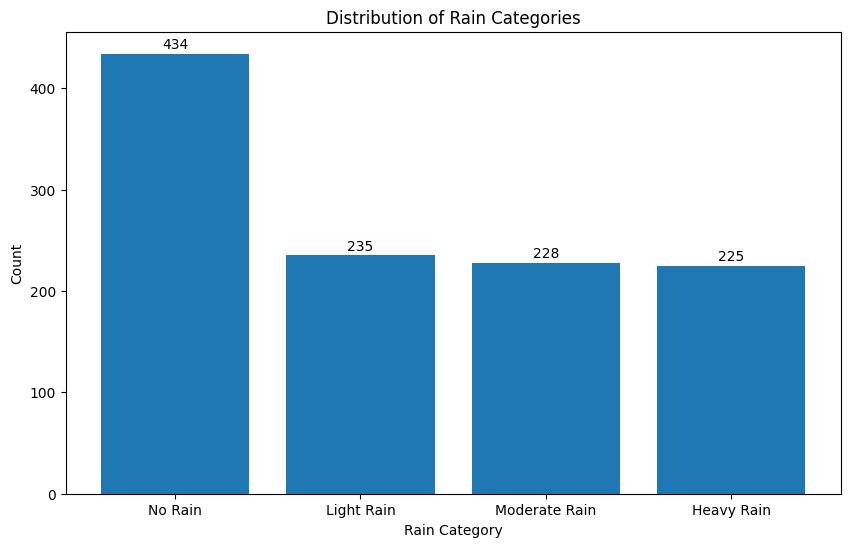

Rain category distribution:
rain_label
No Rain          434
Light Rain       235
Heavy Rain       228
Moderate Rain    225
Name: count, dtype: int64


In [88]:
# rain_label' is our target variable (0=No Rain, 1=Light Rain, 2=Moderate Rain, 3=Heavy Rain)
plt.figure(figsize=(10, 6))
rain_counts = df['rain_label'].value_counts()
plt.bar(rain_counts.index, rain_counts.values)
plt.xlabel('Rain Category')
plt.ylabel('Count')
plt.title('Distribution of Rain Categories')
plt.xticks([0, 1, 2, 3], ['No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain'])
for i, v in enumerate(rain_counts.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()

print("Rain category distribution:")
print(df['rain_label'].value_counts())

In [89]:
# Identify numeric columns that should be used as features
feature_columns = [
    'Total Rainfall', 'Dry bulb', 'Wet bulb', 'Humidity', 'Wind speed',
    'hour', 'month', 'day', 'year', 'dayofweek', 'dayofyear',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'rainfall_lag_1', 'humidity_lag_1', 'drybulb_lag_1',
    'rainfall_lag_2', 'humidity_lag_2', 'drybulb_lag_2',
    'rainfall_lag_3', 'humidity_lag_3', 'drybulb_lag_3',
    'rainfall_roll_3h', 'humidity_roll_3h', 'drybulb_roll_3h'
]

# Target column
target_column = 'rain_label'

# Check if all feature columns exist
missing_features = [col for col in feature_columns if col not in df.columns]
if missing_features:
    print(f"Missing features: {missing_features}")
    # Remove missing features
    feature_columns = [col for col in feature_columns if col in df.columns]

print(f"Using {len(feature_columns)} features")
print("Feature columns:", feature_columns)

Using 27 features
Feature columns: ['Total Rainfall', 'Dry bulb', 'Wet bulb', 'Humidity', 'Wind speed', 'hour', 'month', 'day', 'year', 'dayofweek', 'dayofyear', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'rainfall_lag_1', 'humidity_lag_1', 'drybulb_lag_1', 'rainfall_lag_2', 'humidity_lag_2', 'drybulb_lag_2', 'rainfall_lag_3', 'humidity_lag_3', 'drybulb_lag_3', 'rainfall_roll_3h', 'humidity_roll_3h', 'drybulb_roll_3h']


In [90]:
# Extract features and target
X = df[feature_columns].values
y = df[target_column].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target data type: {type(y[0])}")
print(f"Unique target values: {np.unique(y)}")

# Encode target labels if they're strings
if isinstance(y[0], str):
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    print(f"Encoded target values: {np.unique(y_encoded)}")
    print(f"Mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
    y = y_encoded

# Check for NaN values in X (numeric)
print(f"NaN in X: {np.isnan(X).any()}")

# Handle any remaining NaN values (should be none based on earlier check)
if np.isnan(X).any():
    print("Filling NaN values with 0")
    X = np.nan_to_num(X, 0)

print("Data preparation completed!")

Features shape: (1122, 27)
Target shape: (1122,)
Target data type: <class 'str'>
Unique target values: ['Heavy Rain' 'Light Rain' 'Moderate Rain' 'No Rain']
Encoded target values: [0 1 2 3]
Mapping: {'Heavy Rain': 0, 'Light Rain': 1, 'Moderate Rain': 2, 'No Rain': 3}
NaN in X: False
Data preparation completed!


In [91]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling completed!")
print(f"Mean of scaled features: {X_scaled.mean():.4f}")
print(f"Std of scaled features: {X_scaled.std():.4f}")
print(f"Min: {X_scaled.min():.4f}, Max: {X_scaled.max():.4f}")

# Save the scaler for later use
import joblib
joblib.dump(scaler, 'weather_scaler.pkl')
print("Scaler saved as 'weather_scaler.pkl'")

Feature scaling completed!
Mean of scaled features: 0.0000
Std of scaled features: 0.9813
Min: -3.5729, Max: 6.3157
Scaler saved as 'weather_scaler.pkl'


In [92]:
# Create sequences for GRU (handle numpy arrays correctly)
def create_sequences(data, labels, seq_length):
    """
    Create sequences of length seq_length for time series prediction
    """
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i+seq_length])
        y_seq.append(labels[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

# Define sequence length (number of time steps to look back)
SEQ_LENGTH = 12  # Using 12 hours of historical data

# Check if we have enough data
if len(X_scaled) <= SEQ_LENGTH:
    print(f"Warning: Not enough data! Need at least {SEQ_LENGTH+1} samples, but have {len(X_scaled)}")
    SEQ_LENGTH = max(1, len(X_scaled) // 3)
    print(f"Adjusting SEQ_LENGTH to {SEQ_LENGTH}")

# Create sequences
X_seq, y_seq = create_sequences(X_scaled, y, SEQ_LENGTH)

print(f"Original data shape: {X_scaled.shape}")
print(f"Sequences shape: {X_seq.shape}")
print(f"Target shape: {y_seq.shape}")

# Check if we have any sequences
if len(X_seq) == 0:
    raise ValueError("No sequences created! Please reduce SEQ_LENGTH.")

Original data shape: (1122, 27)
Sequences shape: (1110, 12, 27)
Target shape: (1110,)


In [93]:
# Split data into train, validation, and test sets with stratification to maintain class distribution
from sklearn.model_selection import train_test_split

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

# Second split: 80% of remaining for train, 20% for validation (so 64% train, 16% val)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

print("\nTraining set class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {int(u)}: {c} samples ({c/len(y_train)*100:.1f}%)")

Training set shape: (710, 12, 27)
Validation set shape: (178, 12, 27)
Test set shape: (222, 12, 27)

Training set class distribution:
  Class 0: 140 samples (19.7%)
  Class 1: 150 samples (21.1%)
  Class 2: 144 samples (20.3%)
  Class 3: 276 samples (38.9%)


In [94]:
# Build GRU model for multi-class classification
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_gru_model(input_shape, num_classes):
    """
    Build a GRU model for multi-class classification
    """
    model = Sequential([
        Input(shape=input_shape),
        GRU(64, return_sequences=True, activation='tanh', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.3),
        BatchNormalization(),
        GRU(32, return_sequences=False, activation='tanh', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    
    return model

# Model parameters
input_shape = (SEQ_LENGTH, X_train.shape[2])
num_classes = len(np.unique(y))

print(f"Input shape: {input_shape}")
print(f"Number of classes: {num_classes}")

# Build model
model = build_gru_model(input_shape, num_classes)

# Compile model with a slightly lower learning rate
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

Input shape: (12, 27)
Number of classes: 4


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_6 (GRU)                     │ (None, 12, 64)         │        17,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,116 (109.83 KB)

 Trainable params: 27,988 (109.33 KB)

 Non-trainable params: 128 (512.00 B)

In [95]:
# Define callbacks for training
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

# Model checkpoint to save best model
model_checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/c/ai/weather/uncompressed-gru/best_gru_weather_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

callbacks = [early_stopping, reduce_lr, model_checkpoint]
print("Callbacks defined successfully!")

Callbacks defined successfully!


In [96]:
# Train the model with class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights to handle imbalance
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights for imbalanced data:")
for i, weight in enumerate(class_weights):
    print(f"  Class {i}: {weight:.4f}")

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,  # Reduced batch size for better generalization
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print("Training completed!")

Class weights for imbalanced data:
  Class 0: 1.2679
  Class 1: 1.1833
  Class 2: 1.2326
  Class 3: 0.6431
Epoch 1/100
43/45 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2450 - loss: 1.6259
Epoch 1: val_accuracy improved from None to 0.46067, saving model to /content/drive/MyDrive/c/ai/weather/uncompressed-gru/best_gru_weather_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/c/ai/weather/uncompressed-gru/best_gru_weather_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.2789 - loss: 1.5431 - val_accuracy: 0.4607 - val_loss: 1.4130 - learning_rate: 5.0000e-04
Epoch 2/100
39/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4200 - loss: 1.4157
Epoch 2: val_accuracy improved from 0.46067 to 0.51685, saving model to /content/drive/MyDrive/c/ai/weather/uncompressed-gru/best_gru_weather_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/c/ai/weather/uncompressed-gru/best_gru_weather_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

Best validation loss: 0.5109 at epoch 62
Best validation accuracy: 0.8989 at epoch 62


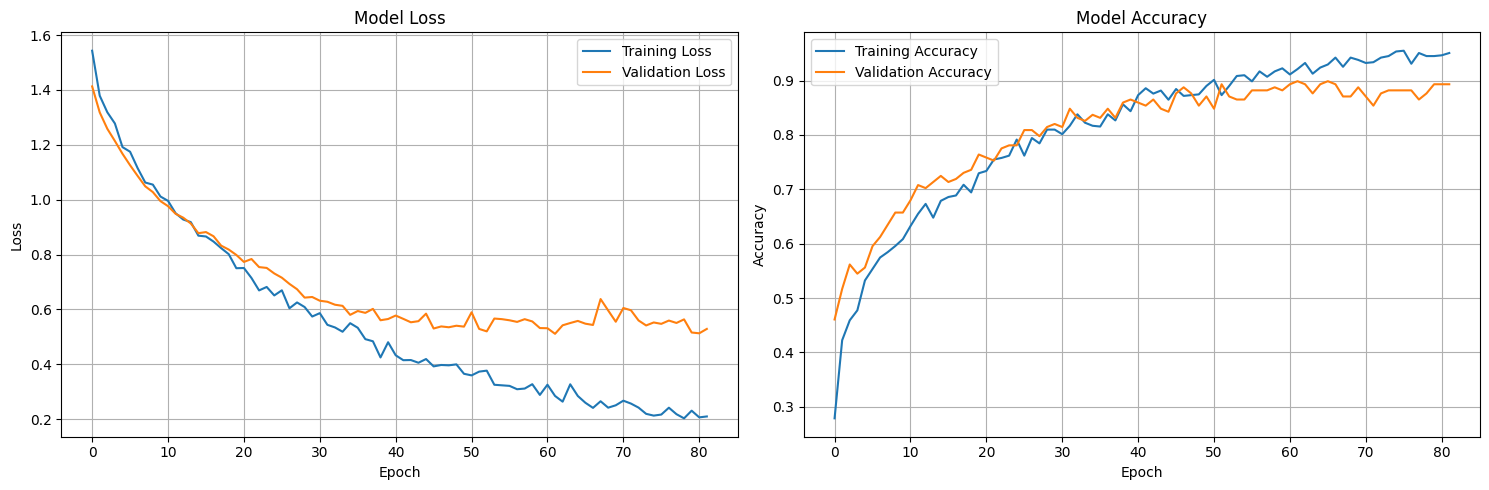

In [97]:
# Plot training history and print best validation metrics
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
if 'loss' in history.history and 'val_loss' in history.history:
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Model Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Print best validation loss
    best_loss_epoch = np.argmin(history.history['val_loss'])
    print(f"Best validation loss: {history.history['val_loss'][best_loss_epoch]:.4f} at epoch {best_loss_epoch+1}")

# Plot accuracy
if 'accuracy' in history.history and 'val_accuracy' in history.history:
    axes[1].plot(history.history['accuracy'], label='Training Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_title('Model Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    
    # Print best validation accuracy
    best_acc_epoch = np.argmax(history.history['val_accuracy'])
    print(f"Best validation accuracy: {history.history['val_accuracy'][best_acc_epoch]:.4f} at epoch {best_acc_epoch+1}")

plt.tight_layout()
plt.show()

In [98]:
# Evaluate on test set
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load best model
best_model = load_model('/content/drive/MyDrive/c/ai/weather/uncompressed-gru/best_gru_weather_model.keras')

# Make predictions
y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Classification report
class_names = ['No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain']
# Only include classes that exist in the data
existing_classes = np.unique(y_test)
class_names_filtered = [class_names[i] for i in existing_classes]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names_filtered))

Test Accuracy: 0.8829

Classification Report:
               precision    recall  f1-score   support

      No Rain       0.86      0.86      0.86        44
   Light Rain       0.87      0.87      0.87        47
Moderate Rain       0.88      0.80      0.84        45
   Heavy Rain       0.90      0.94      0.92        86

     accuracy                           0.88       222
    macro avg       0.88      0.87      0.87       222
 weighted avg       0.88      0.88      0.88       222



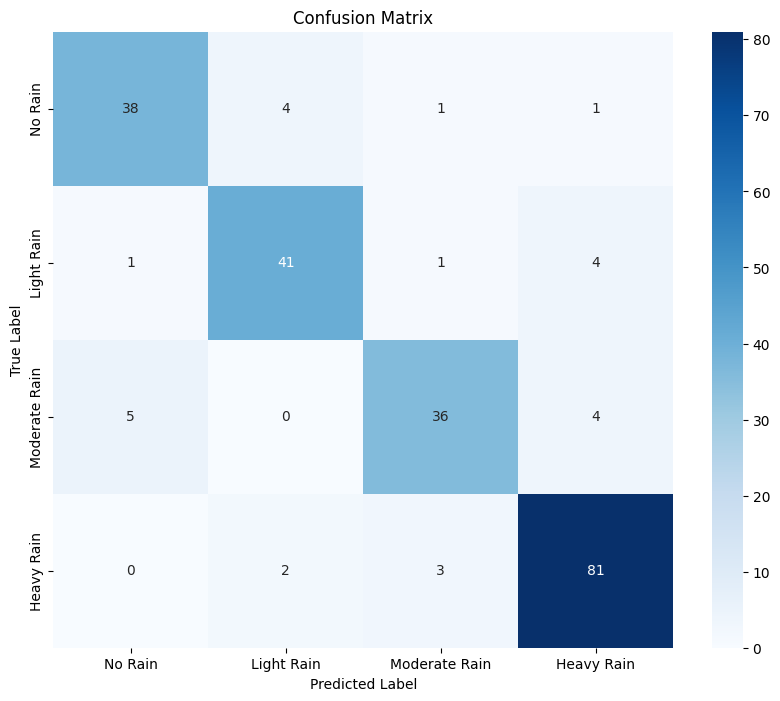


Per-class accuracy:
  No Rain: 38/44 (86.36%)
  Light Rain: 41/47 (87.23%)
  Moderate Rain: 36/45 (80.00%)
  Heavy Rain: 81/86 (94.19%)


In [99]:
# Confusion Matrix and per-class accuracy
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_filtered, 
            yticklabels=class_names_filtered)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i, class_name in enumerate(class_names_filtered):
    class_correct = cm[i, i]
    class_total = np.sum(cm[i, :])
    class_acc = class_correct / class_total if class_total > 0 else 0
    print(f"  {class_name}: {class_correct}/{class_total} ({class_acc:.2%})")

In [ ]:
# Save the model and preprocessing objects
import json
import joblib

# Save the best model
best_model.save('/content/drive/MyDrive/c/ai/weather/uncompressed-gru/gru_weather_model.h5')
print("Model saved as 'gru_weather_model.h5'")

# Save the scaler
joblib.dump(scaler, '/content/drive/MyDrive/c/ai/weather/uncompressed-gru/scaler.pkl')
print("Scaler saved as 'scaler.pkl'")

# Save feature columns list
with open('/content/drive/MyDrive/c/ai/weather/uncompressed-gru/feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)
print("Feature columns saved as 'feature_columns.json'")

# Save label encoder 
if 'label_encoder' in locals():
    joblib.dump(label_encoder, '/content/drive/MyDrive/c/ai/weather/uncompressed-gru/label_encoder.pkl')
    print("Label encoder saved as 'label_encoder.pkl'")

print("\nAll artifacts saved successfully!")

Model saved as 'gru_weather_model.h5'
Scaler saved as 'scaler.pkl'
Feature columns saved as 'feature_columns.json'
Label encoder saved as 'label_encoder.pkl'

All artifacts saved successfully!


In [101]:
# Prediction function 
def predict_weather(model, scaler, label_encoder, sequence_length, new_data, feature_columns):
    """
    Make predictions on new weather data
    
    Parameters:
    - model: trained GRU model
    - scaler: fitted StandardScaler
    - label_encoder: fitted LabelEncoder for target classes
    - sequence_length: number of time steps used in training
    - new_data: DataFrame with the same feature columns as training data
    - feature_columns: list of feature column names
    
    Returns:
    - predictions: array of predicted class labels (original string labels)
    - probabilities: array of class probabilities
    - predicted_indices: array of predicted class indices
    """
    # Ensure new_data has all required features
    missing_features = [col for col in feature_columns if col not in new_data.columns]
    if missing_features:
        raise ValueError(f"Missing features: {missing_features}")
    
    # Select only the required features
    new_data_filtered = new_data[feature_columns]
    
    # Check for NaN values
    if new_data_filtered.isnull().any().any():
        print("Warning: NaN values detected in input data. Filling with 0.")
        new_data_filtered = new_data_filtered.fillna(0)
    
    # Scale the features
    scaled_data = scaler.transform(new_data_filtered.values)
    
    # Create sequences
    X_pred = []
    for i in range(len(scaled_data) - sequence_length + 1):
        X_pred.append(scaled_data[i:i+sequence_length])
    
    if len(X_pred) == 0:
        raise ValueError(f"Not enough data to create a sequence. Need at least {sequence_length} samples.")
    
    X_pred = np.array(X_pred)
    
    # Make predictions
    probabilities = model.predict(X_pred, verbose=0)
    predicted_indices = np.argmax(probabilities, axis=1)
    
    # Convert indices back to original labels
    predictions = label_encoder.inverse_transform(predicted_indices)
    
    return predictions, probabilities, predicted_indices

# Test the prediction function 
print("Testing prediction function...")
if len(X_test) > 0:
    # Use a sample from test set
    sample_data = X_test[0:1]
    sample_indices = np.argmax(best_model.predict(sample_data, verbose=0), axis=1)
    sample_labels = label_encoder.inverse_transform(sample_indices)
    print(f"Sample prediction: {sample_labels[0]}")
    print("Prediction function test successful!")
else:
    print("No test data available for testing prediction function.")

Testing prediction function...
Sample prediction: No Rain
Prediction function test successful!


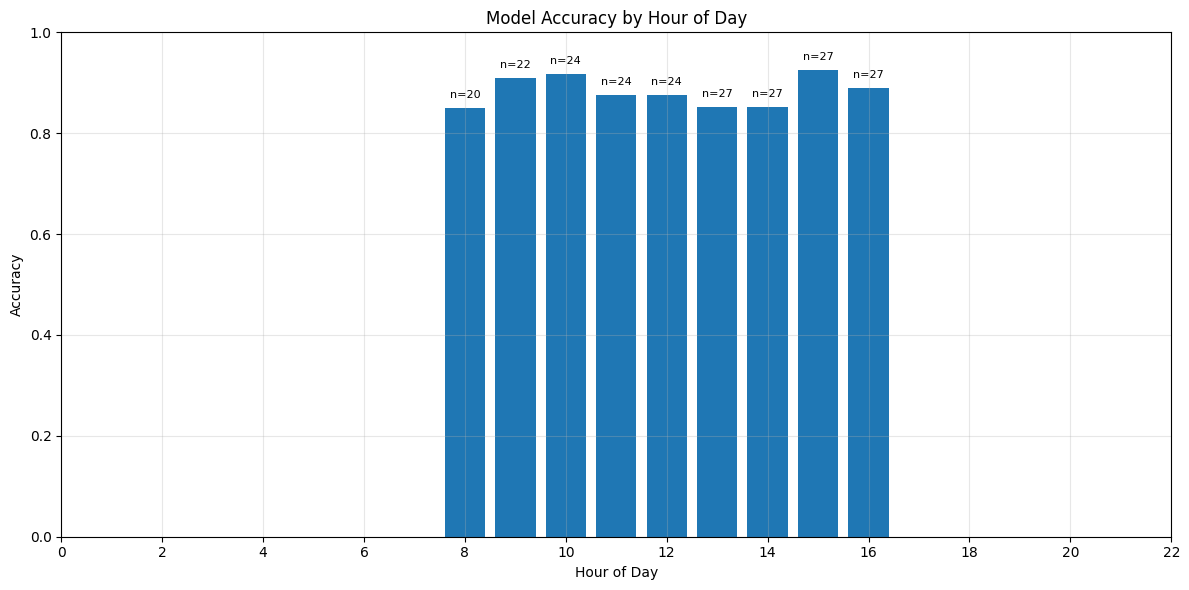

Hourly accuracy:
  Hour 08: 85.00% (20 samples)
  Hour 09: 90.91% (22 samples)
  Hour 10: 91.67% (24 samples)
  Hour 11: 87.50% (24 samples)
  Hour 12: 87.50% (24 samples)
  Hour 13: 85.19% (27 samples)
  Hour 14: 85.19% (27 samples)
  Hour 15: 92.59% (27 samples)
  Hour 16: 88.89% (27 samples)


In [102]:
# Analyze model performance by time of day
# Reconstruct original time information for analysis
# We need to get the original datetime information

# Get the datetime column if available
if 'datetime' in df.columns:
    # Get the corresponding test indices from the original data
    # This is approximate since we created sequences
    test_indices = []
    for i in range(len(X_seq)):
        if i + SEQ_LENGTH >= len(X_scaled) - len(X_test):
            test_indices.append(i + SEQ_LENGTH)
    
    # Get time of day for test samples
    test_datetimes = df.iloc[test_indices]['datetime'].values if len(test_indices) == len(y_test) else None
    
    if test_datetimes is not None and len(test_datetimes) == len(y_test):
        # Extract hour
        test_hours = [pd.to_datetime(dt).hour for dt in test_datetimes]
        
        # Analyze accuracy by hour
        plt.figure(figsize=(12, 6))
        hour_accuracy = []
        for hour in range(24):
            hour_mask = np.array(test_hours) == hour
            if np.sum(hour_mask) > 0:
                hour_acc = accuracy_score(y_test[hour_mask], y_pred[hour_mask])
                hour_accuracy.append((hour, hour_acc, np.sum(hour_mask)))
        
        hours, accuracies, counts = zip(*hour_accuracy)
        plt.bar(hours, accuracies)
        plt.xlabel('Hour of Day')
        plt.ylabel('Accuracy')
        plt.title('Model Accuracy by Hour of Day')
        plt.xticks(range(0, 24, 2))
        plt.ylim(0, 1)
        plt.grid(True, alpha=0.3)
        
        # Add count annotations
        for i, (h, acc, count) in enumerate(hour_accuracy):
            plt.text(h, acc + 0.02, f'n={count}', ha='center', fontsize=8)
        
        plt.tight_layout()
        plt.show()
        
        print("Hourly accuracy:")
        for hour, acc, count in hour_accuracy:
            print(f"  Hour {hour:02d}: {acc:.2%} ({count} samples)")

In [103]:
# Save training summary
print("="*50)
print("TRAINING SUMMARY")
print("="*50)
print(f"Total samples: {len(X_seq)}")
print(f"Sequence length: {SEQ_LENGTH}")
print(f"Number of features: {len(feature_columns)}")
print(f"Number of classes: {num_classes}")
print(f"Class distribution in training: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Best validation loss: {min(history.history['val_loss']):.4f}")
print("="*50)

# Save summary to file
with open('training_summary.txt', 'w') as f:
    f.write("TRAINING SUMMARY\n")
    f.write("="*50 + "\n")
    f.write(f"Total samples: {len(X_seq)}\n")
    f.write(f"Sequence length: {SEQ_LENGTH}\n")
    f.write(f"Number of features: {len(feature_columns)}\n")
    f.write(f"Number of classes: {num_classes}\n")
    f.write(f"Class distribution in training: {dict(zip(*np.unique(y_train, return_counts=True)))}\n")
    f.write(f"Training samples: {len(X_train)}\n")
    f.write(f"Validation samples: {len(X_val)}\n")
    f.write(f"Test samples: {len(X_test)}\n")
    f.write(f"Test accuracy: {test_accuracy:.4f}\n")
    f.write(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}\n")
    f.write(f"Best validation loss: {min(history.history['val_loss']):.4f}\n")

print("Training summary saved to 'training_summary.txt'")
print("\nModel training completed successfully!")

TRAINING SUMMARY
Total samples: 1110
Sequence length: 12
Number of features: 27
Number of classes: 4
Class distribution in training: {0: 140, 1: 150, 2: 144, 3: 276}
Training samples: 710
Validation samples: 178
Test samples: 222
Test accuracy: 0.8829
Best validation accuracy: 0.8989
Best validation loss: 0.5109
Training summary saved to 'training_summary.txt'

Model training completed successfully!


In [104]:
# save the processed data for future use (so we don't have to repeat all the preprocessing steps when we want to retrain or analyze the model later)
np.savez('/content/drive/MyDrive/c/ai/weather/uncompressed-gru/weather_sequence_data.npz',
         X_train=X_train, y_train=y_train,
         X_val=X_val, y_val=y_val,
         X_test=X_test, y_test=y_test)

In [105]:
np.savez('/content/weather_sequence_data.npz',
         X_train=X_train, y_train=y_train,
         X_val=X_val, y_val=y_val,
         X_test=X_test, y_test=y_test)

In [106]:
import os
os.listdir('/content/')


['.config',
 'weather_sequence_data.npz',
 'drive',
 '.ipynb_checkpoints',
 'training_summary.txt',
 'weather_compression_metrics.csv',
 'weather_model_final_quantized.tflite',
 'weather_scaler.pkl',
 'data',
 'sample_data']